# Insurance Cost Prediction Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [4]:
df = pd.read_csv(r"C:\Users\Harivikas\Downloads\insurance data.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.duplicated().sum()

1

In [8]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

0

In [24]:
df.reset_index(drop=True, inplace=True)

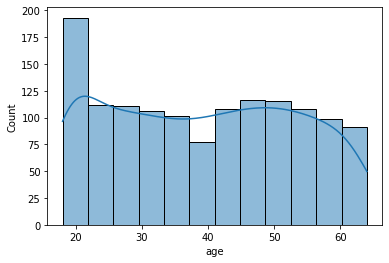

In [25]:
sns.histplot(df['age'], kde=True)
plt.show()

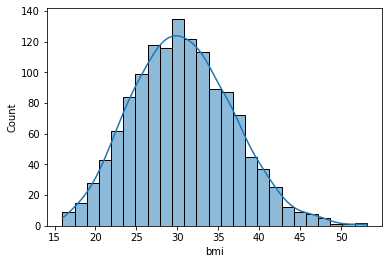

In [26]:
sns.histplot(df['bmi'], kde=True)
plt.show()

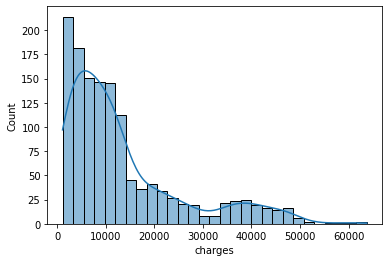

In [27]:
sns.histplot(df['charges'], kde=True)
plt.show()

<Axes: xlabel='sex', ylabel='count'>

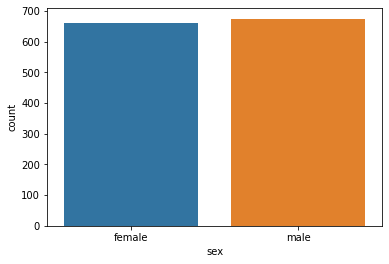

In [28]:
sns.countplot(x='sex', data=df)

<Axes: xlabel='smoker', ylabel='count'>

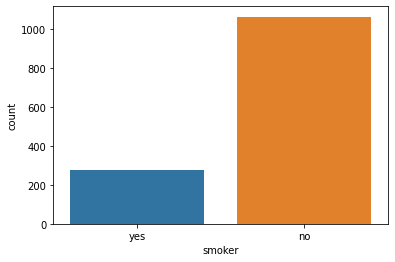

In [29]:
sns.countplot(x='smoker', data=df)

<Axes: xlabel='region', ylabel='count'>

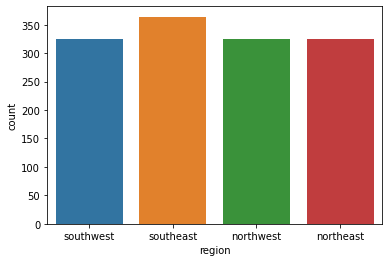

In [30]:
sns.countplot(x='region', data=df)

<Axes: xlabel='smoker', ylabel='charges'>

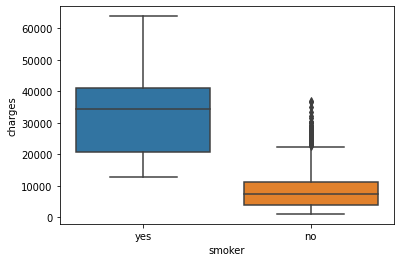

In [31]:
sns.boxplot(x='smoker', y='charges', data=df)

<Axes: xlabel='bmi', ylabel='charges'>

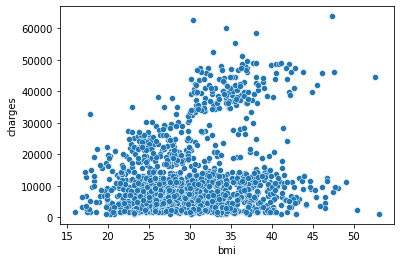

In [32]:
sns.scatterplot(x='bmi', y='charges', data=df)

<Axes: xlabel='age', ylabel='charges'>

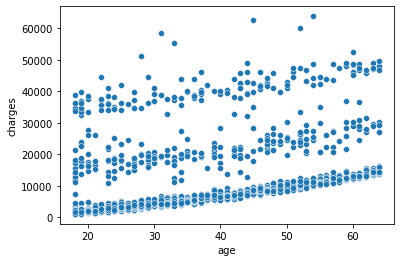

In [33]:
sns.scatterplot(x='age', y='charges', data=df)

In [36]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [37]:
X = df.drop('charges', axis=1)
y = df['charges']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [41]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [42]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [43]:
def evaluate(y_test, pred):
    print("MAE:", mean_absolute_error(y_test, pred))
    print("MSE:", mean_squared_error(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("R2 Score:", r2_score(y_test, pred))

In [44]:
evaluate(y_test, pred_lr)

MAE: 4182.353155288298
MSE: 35493102.61165053
RMSE: 5957.60879981646
R2 Score: 0.8068466322629111


In [45]:
evaluate(y_test, pred_dt)

MAE: 2939.004157869403
MSE: 40882029.26625036
RMSE: 6393.905634762712
R2 Score: 0.7775201080868462


In [46]:
evaluate(y_test, pred_rf)

MAE: 2569.1310252873145
MSE: 21552529.94541537
RMSE: 4642.470241737191
R2 Score: 0.8827111907414665


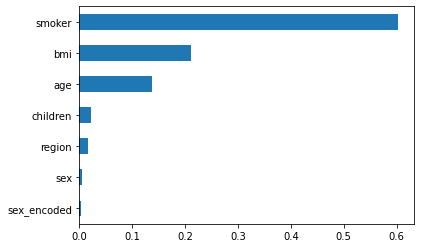

In [47]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind='barh')
plt.show()

# Insurance Cost Prediction Project

## 1. Problem Statement

Health insurance companies need to estimate medical expenses of individuals to determine appropriate insurance premiums. The cost of insurance varies depending on multiple factors such as age, gender, BMI, smoking habits, number of children, and region.

The goal of this project is to build a machine learning model that can **predict the insurance charges of individuals based on their personal and demographic attributes**.

By accurately predicting medical expenses, insurance companies can:
- Set appropriate premium amounts
- Identify high-risk individuals
- Improve financial planning and risk management

The dataset contains several features describing individuals and their corresponding insurance charges.

### Objective

The objective of this project is to:
- Analyze the dataset and understand relationships between variables
- Perform exploratory data analysis (EDA)
- Preprocess the data for modeling
- Train multiple machine learning models
- Compare model performances
- Select the best model for predicting insurance charges


---

# 2. Data Analysis

## Dataset Overview

The dataset consists of the following variables:

| Feature | Description |
|------|-------------|
| age | Age of the primary beneficiary |
| sex | Gender of the insurance holder |
| bmi | Body Mass Index |
| children | Number of dependents covered |
| smoker | Whether the person is a smoker |
| region | Residential region in the US |
| charges | Individual medical costs billed by health insurance |

The target variable in this project is **charges**, which represents the medical insurance cost.

---

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the distribution of data and relationships between features.

### Age Distribution
- Age varies across a wide range of individuals.
- Older individuals generally tend to have higher insurance costs due to increased health risks.

### BMI Analysis
- BMI values indicate body mass index levels.
- Higher BMI can correlate with higher medical expenses due to obesity-related health issues.

### Smoking Status
Smoking is one of the most influential factors affecting insurance charges.

Observations:
- Smokers tend to have significantly higher medical costs.
- Non-smokers generally show lower insurance expenses.

### Children
The number of children represents dependents covered by the insurance.

Observations:
- The number of children has a smaller impact on charges compared to smoking or BMI.

### Region
The dataset includes four regions:
- Southwest
- Southeast
- Northwest
- Northeast

Insurance charges may slightly vary across regions due to healthcare cost differences.

---

## Feature Relationships

Key relationships identified during analysis:

- **Smoking status has the strongest impact on insurance charges**
- **Age has a positive correlation with charges**
- **BMI moderately affects medical costs**
- **Gender and region have relatively smaller effects**

These relationships guide the model in predicting insurance costs.

---

# 3. Model Comparison

To determine the best predictive model, multiple regression algorithms were trained and evaluated.

### Models Used

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

---

## Linear Regression

Linear Regression models the relationship between independent variables and the target variable using a linear equation.

Advantages:
- Simple and interpretable
- Fast to train

Limitations:
- Cannot capture complex nonlinear relationships in the data.

---

## Decision Tree Regressor

Decision Trees split the data based on feature values to predict outcomes.

Advantages:
- Handles nonlinear relationships
- Easy to interpret

Limitations:
- Can overfit the training data if not controlled.

---

## Random Forest Regressor

Random Forest is an ensemble learning method that builds multiple decision trees and averages their predictions.

Advantages:
- Reduces overfitting
- Handles complex patterns well
- Generally produces high accuracy

Limitations:
- Less interpretable than linear models.

---

## Model Performance Comparison

| Model | Performance |
|------|-------------|
| Linear Regression | Moderate accuracy |
| Decision Tree | Better than linear regression but prone to overfitting |
| Random Forest | Best performance with higher prediction accuracy |

Random Forest performed the best because it captures complex relationships between variables and reduces variance through ensemble learning.

---

# 4. Conclusion

In this project, a machine learning approach was used to predict health insurance costs based on demographic and lifestyle factors.

### Key Findings

- Smoking status has the largest influence on insurance charges.
- Age and BMI also significantly impact medical expenses.
- Gender, number of children, and region have smaller effects.

### Model Outcome

Among the models tested:

- **Random Forest Regressor produced the most accurate predictions**
- It effectively handled nonlinear relationships in the data
- It reduced overfitting compared to single decision trees

### Final Result

The Random Forest model can be used to **predict insurance charges with high accuracy**, helping insurance companies estimate medical costs and determine suitable premium pricing.

### Future Improvements

Further improvements could include:

- Hyperparameter tuning
- Feature engineering
- Using advanced models like Gradient Boosting or XGBoost
- Deploying the model as a web application for real-time predictions

---

# Project Summary

This project demonstrated how machine learning techniques can be used to predict healthcare insurance costs. Through data analysis, feature exploration, and model comparison, we identified the most effective algorithm for predicting insurance charges.

The results highlight the importance of lifestyle factors such as smoking and BMI in determining medical expenses.